### Validates the BR08 discrete variance decay algorithm for numerical mixing.
Analyze output of MPAS-O setup as a doubly-periodic channel. Initial zonal velocity only, all other debug flags configured such that the model behaves as a linear advection equation.

In [1]:
#Packages 
import numpy as np
import xarray as xr
import glob
import cmocean.cm as cmo
import matplotlib.cm as cmx
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
warnings.filterwarnings("ignore") #turns off annoying warnings
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter
import mosaic
from matplotlib.colors import SymLogNorm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import binned_statistic

In [2]:
def center_vertices(dsg, hres):
    # Clean up the indexing so the domain is centered for plotting

    # Original vertices (x,y) arrays
    xv = dsg.xVertex.values
    yv = dsg.yVertex.values
    
    # Compute the new vertices based on your filtering and offset logic:
    
    # 1. Extract verticesOnCell (assuming shape: [nCells, maxVerticesPerCell])
    voc = dsg.verticesOnCell.values
    
    # 2. Build verts as in your snippet (shape: [nCells, maxVerticesPerCell, 2])
    verts = np.dstack((xv[voc - 1], yv[voc - 1]))
    nverts = np.sum(voc != 0, axis=1)
    verts_list = [vert[:n] for vert, n in zip(verts, nverts)]
    
    # 3. Filter verts using np.ptp
    idx = [np.ptp(vert[:, 0]) < 50000 for vert in verts_list]
    verts_filtered = np.array(verts_list)[idx]
    
    # 4. Copy and apply offsets
    nuverts = verts_filtered.copy()
    m_dsx = hres
    nuverts[:, :, 0] += m_dsx / 2
    nuverts[:, :, 1] -= m_dsx
    
    # Now, update dsg's xVertex and yVertex arrays accordingly:
    # But note: verts are grouped by cell, so we need to flatten and assign properly.
    
    # Because verts_filtered is a filtered subset of verts_list,
    # you should update only those cells where idx is True.
    
    # Get indices of cells that passed filter
    filtered_cells = np.where(idx)[0]
    
    # Create copies of xVertex and yVertex to modify
    new_xVertex = xv.copy()
    new_yVertex = yv.copy()
    
    # Loop over filtered cells and update the corresponding vertex coords
    for cell_i, verts_cell in zip(filtered_cells, nuverts):
        nv = verts_cell.shape[0]  # number of vertices for this cell
        vertex_inds = voc[cell_i, :nv] - 1  # zero-based vertex indices for this cell
        new_xVertex[vertex_inds] = verts_cell[:, 0]
        new_yVertex[vertex_inds] = verts_cell[:, 1]
    
    # Assign back to dsg (if dsg is an xarray Dataset or DataArray)
    dsg['xVertex'].values = new_xVertex
    dsg['yVertex'].values = new_yVertex

In [3]:
### Open output 
rootdir = '/pscratch/sd/d/dylan617/mnum_val/br08_validation/'

# Load datasets
dsi = xr.open_dataset(rootdir + 'channel_init.nc')
dso = xr.open_dataset(rootdir + 'output.nc')
dsd = xr.open_dataset(rootdir + 'analysis_members/discreteVarianceDecay.0001-01-01.nc')
center_vertices(dsi, 1.0) # Call fixing of vertices, second arg is horz res in meters

# dso.xtime

### Check that the initial velocity is equal to 1 in the zonal direction and zero in the meridional

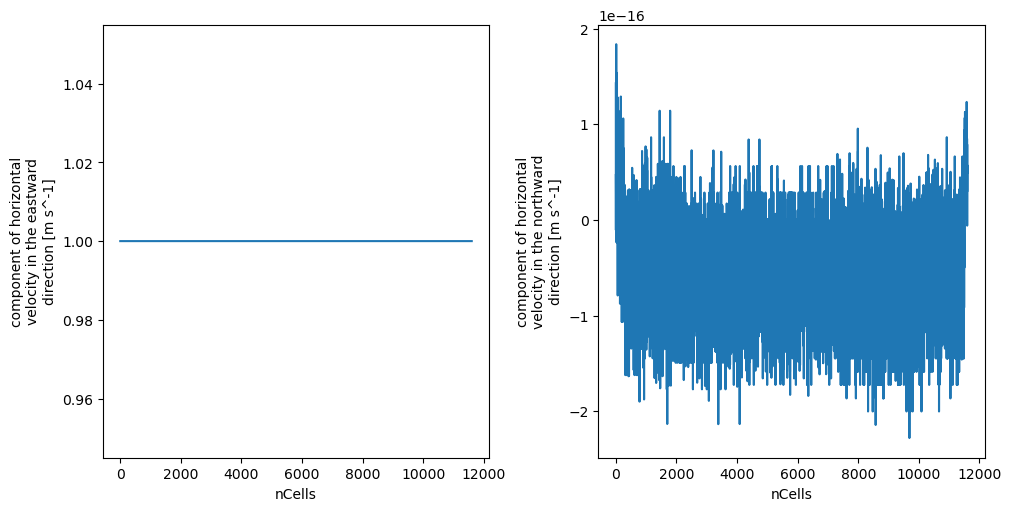

In [4]:
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10,5))
dso.velocityZonal[0].plot(ax=ax[0])
dso.velocityMeridional[0].plot(ax=ax[1])

### Now check the last timestep 

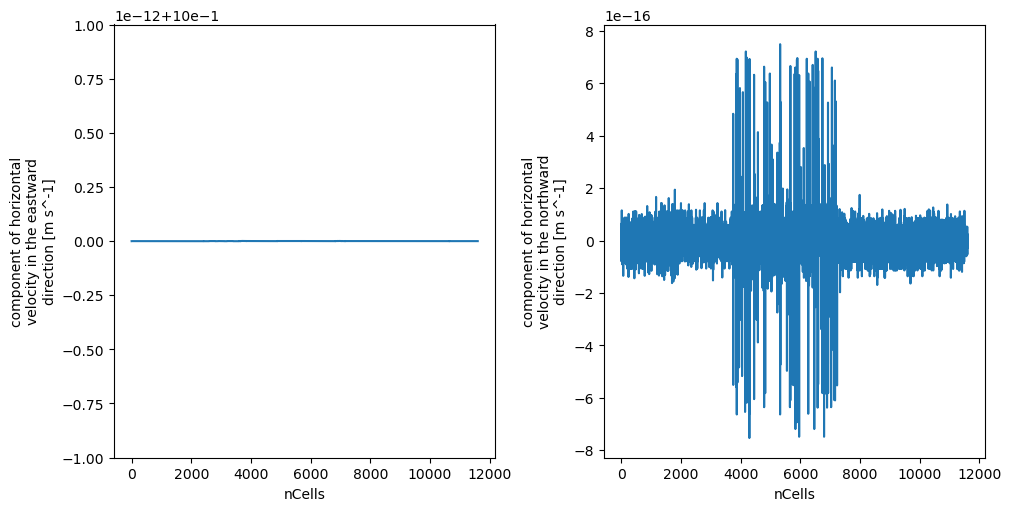

In [5]:
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10,5))
dso.velocityZonal[-1].plot(ax=ax[0])
dso.velocityMeridional[-1].plot(ax=ax[1])

### Plot a plan view at t = 0 and t = 100 sec

In [6]:
# Mosaic descriptor object, needed to plot the polygons
descriptor = mosaic.Descriptor(dsi,use_latlon=False)

# Used for plotting mnum on a diverging log colorbar
# Otherwise the extrema look the same for most cmocean maps. That is, 
# you can't tell dark reds or blues apart. 
def truncate_colormap(cmap, minval=0.0, maxval=0.8, n=256):
    """Truncates a colormap to use only part of the range."""
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

curl = truncate_colormap(plt.get_cmap('cmo.curl'), 0.1, 0.9)

# Helper to safely compute log10 for plotting, otherwise it is masked for 
# very small values
def safe_log10(data, floor=1e-10):
    """Compute log10 of xarray DataArray safely, keeping dimensions and attrs."""
    # Replace nonpositive or nonfinite values with floor
    data_clean = data.where((data > 0) & np.isfinite(data), other=floor)
    return np.log10(data_clean)

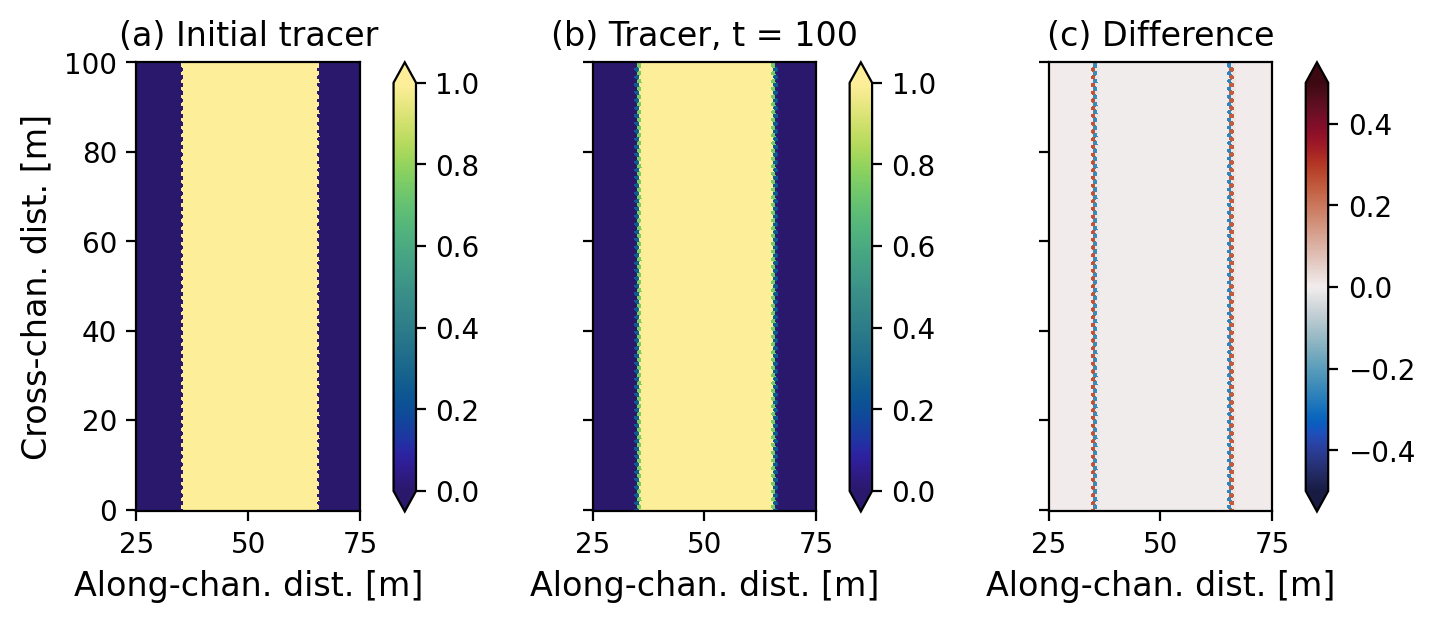

In [7]:
z = 0; t=-1
fig, axes = plt.subplots(1, 3, figsize=(7, 3), constrained_layout=True, dpi = 200)

# Panel (a): Salinity
c = mosaic.polypcolor(axes[0], descriptor,
                      dsi.salinity.isel(nVertLevels=z, Time=0),
                      cmap=cmo.haline, vmin=0, vmax=1,
                      antialiaseds=False)
fig.colorbar(c, ax=axes[0], extend='both')

# Panel (a): Salinity
c = mosaic.polypcolor(axes[1], descriptor,
                      dso.temperature.isel(nVertLevels=z, Time=t),
                      cmap=cmo.haline, vmin=0, vmax=1,
                      antialiaseds=False)
fig.colorbar(c, ax=axes[1], extend='both')

# # Panel (a): Salinity
c = mosaic.polypcolor(axes[2], descriptor,
                      dso.temperature.isel(nVertLevels=z, Time=t)-dso.salinity.isel(nVertLevels=z, Time=0),
                      cmap=cmo.balance, vmin=-.5, vmax=.5,
                      antialiaseds=False)

fig.colorbar(c, ax=axes[2], extend='both')


for ax in axes:
    # ax.set_xticks(np.arange(0, 350000, 50000))
    # ax.set_yticks(np.arange(0, 350000, 50000))
    ax.set_xlim(25,75)
    # ax.set_ylim(0, 101)
    ax.set_aspect(1.0)
    # ax.set_xticklabels([str(x) for x in ax.get_xticks()])
    # ax.set_yticklabels([str(y) for y in ax.get_yticks()])
    ax.set_xlabel('Along-chan. dist. [m]', fontsize=12)
    ax.set_ylabel('Cross-chan. dist. [m]', fontsize=12)

for ax in axes[1:]:
    ax.set_ylabel('')
    ax.set_yticklabels('')

axes[0].set_title('(a) Initial tracer')
axes[1].set_title('(b) Tracer, t = 100')
axes[2].set_title(r'(c) Difference')
plt.savefig('plan_view_channel.png',dpi=200, bbox_inches='tight')

### Meridional average 

In [8]:
# --- Load MPAS cell-centered data ---
xCell = dsi.xCell.values          # e.g., [0.5, 1.5, 2.5, ..., 100.0]
salt  = dso.salinity.isel(Time=-1, nVertLevels=0).values
dvd   = dsd.chiSpurSaltBR08.isel(Time=-1, nVertLevels=0).values

# --- Define bin edges so bins are centered at cell centers ---
dx = 1.0
x_bins = np.arange(0, L + dx, dx)     # edges: 0, 1, ..., 100
x_centers = np.arange(0.5, L + 0.5, dx)  # centers: 0.5, 1.5, ..., 100.5

# --- Compute meridional mean (in 1 m bins) ---
meridional_avg, _, _ = binned_statistic(xCell, salt, bins=x_bins, statistic='mean')
meridional_avg_dvd, _, _ = binned_statistic(xCell, dvd, bins=x_bins, statistic='mean')

# Aanlytical
def s_xt(x, t, u, L):
    shifted_x = (x - u * t) % L
    return s0(shifted_x)

# --- Parameters ---
L = 100       # domain length in meters
u = 1         # advection speed in m/s
t2 = 100     # time in seconds (e.g., after 100 seconds)

# --- Analytical solution at same centers ---
s_t1 = s_xt(x_centers, t2, u, L)


NameError: name 'L' is not defined

In [ ]:
# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True, constrained_layout=True)

axs[0].plot(x_centers, s_t1, label='Exact', marker='x', markersize=2, lw=0.9, c = 'r')
axs[0].plot(x_centers, meridional_avg, label='MPAS-O, t=100s',
             marker='o', markersize=2, lw=0.9, color='black')
axs[0].set_title('(a) Tracer')
axs[0].legend()
axs[0].grid()

axs[1].plot(x_centers, meridional_avg_dvd, marker='o', markersize=2, lw=0.9, color='black')
axs[1].set_xlabel('X [m]')
axs[1].set_ylabel(r'[(tracer)$^2$/s]')
axs[1].set_title(r'(b) $\mathcal{M}_{num}$')
axs[1].grid()

plt.savefig('1d_adv_mer_avg.png', dpi=300, bbox_inches='tight')
plt.show()

### Compute volume-integrated salinity variance budget

In [9]:
# --- Compute differential volume ---
dV = (dso.layerThickness * dsi.areaCell).astype(np.float64)

# --- Total volume ---
V = dV.sum(dim=['nVertLevels', 'nCells']).astype(np.float64)

# --- Mean salinity ---
sbar = ((dso.salinity * dV).sum(dim=['nVertLevels', 'nCells']) / V).astype(np.float64)

# --- Salinity variance ---
svar = ((dso.salinity - sbar)**2).astype(np.float64)

# --- Time step ---
dt = np.float64(0.5)

# --- Time tendency of salinity variance  ---
tend = (((svar.diff('Time') / dt) * dV.isel(Time=slice(1, None))))
tend = tend.sum(dim=['nVertLevels', 'nCells']).astype(np.float64)

# --- Numerical mixing diagnostic (also AB2) ---
# chiSpurSaltBR08 is the AB2-based estimate of mixing tendency
mnum_dv = ((dsd.chiSpurSaltBR08 * dsi.areaCell * dso.layerThickness)
           .sum(dim=['nVertLevels', 'nCells'])
           .astype(np.float64))

# --- Align mnum with tend, this was a pain to figure out ---
# The output is every DT, starting at t = 0, which is the initial condition. 
# Mnum isn't defined at t = 0, and AB2 timestepping introduces a 2-timestep lag.
# Doing a diff shifts time forward by 1. Here is a sketch
# -----------------------------------------------------------------
# Model timesteps (S[t]):
# t0       t1       t2       t3       t4       t5       t6       t7
# |Euler |AB2  |AB2  |AB2  |AB2  |AB2  |AB2  |AB2  |

# Raw numerical mixing (mnum_dv):
# t0       t1       t2       t3       t4       t5       t6       t7
# |-----|-----|-----|-----|-----|-----|-----|-----|

# Align for AB2 lag (shift forward by 2):
# mnum_aligned = -mnum_dv[2:len(tend)+2]
# t0       t1       t2       t3       t4       t5
#          |-----|-----|-----|-----|-----|-----|
#          mnum_aligned[0]  ← corresponds to tend[0]
#          mnum_aligned[1]  ← corresponds to tend[1]
#          ...

# Variance tendency (tend):
# t0       t1       t2       t3       t4       t5
# |-----|-----|-----|-----|-----|-----|
# tend[0] = uses S[0..2] (startup contaminated)
# tend[1] = uses S[1..3]
# tend[2] = uses S[2..4]
# tend[3] = uses S[3..5]
# tend[4] = uses S[4..6]

# Discard first 3 steps:
# tend_slice    = tend[3:]        ← tend[3], tend[4], ...
# mnum_slice    = mnum_aligned[3:] ← mnum_aligned[3], ...

# Effectively, the first 5 raw timesteps of S (t0..t4) are ignored:
# - t0: Euler startup
# - t1, t2: initial AB2 affected by startup
# - t3, t4: removed due to slice to align with tend_slice

# After this: tend_slice has len + 1 relative to mnum_slice.
# tend_slice[0]  ↔  mnum_slice[0]  (fully AB2-aligned)
# tend_slice[1]  ↔  mnum_slice[1]

# Also multiply by -1 to match the sign convention of variance tendency
mnum_aligned = -mnum_dv.isel(Time=slice(2, len(tend)+2))

# --- Throw out first 3 timesteps (optional) ---
# Early timesteps may be noisy due to initialization; this keeps arrays aligned
tend_slice = tend[3:]
mnum_slice = mnum_aligned[3:]

print(len(mnum_slice), len(tend_slice))

# --- Compute sums to verify agreement ---
total_tend = tend_slice[:-1].sum()
total_mnum = mnum_slice.sum()

print(f"Sum of tend after first 3 timesteps: {float(total_tend):.12e}")
print(f"Sum of numerical mixing after first 3 timesteps: {float(total_mnum):.12e}")

196 197
Sum of tend after first 3 timesteps: 2.623454784102e+01
Sum of numerical mixing after first 3 timesteps: 2.623454784102e+01


### Plot salinity variance budget 

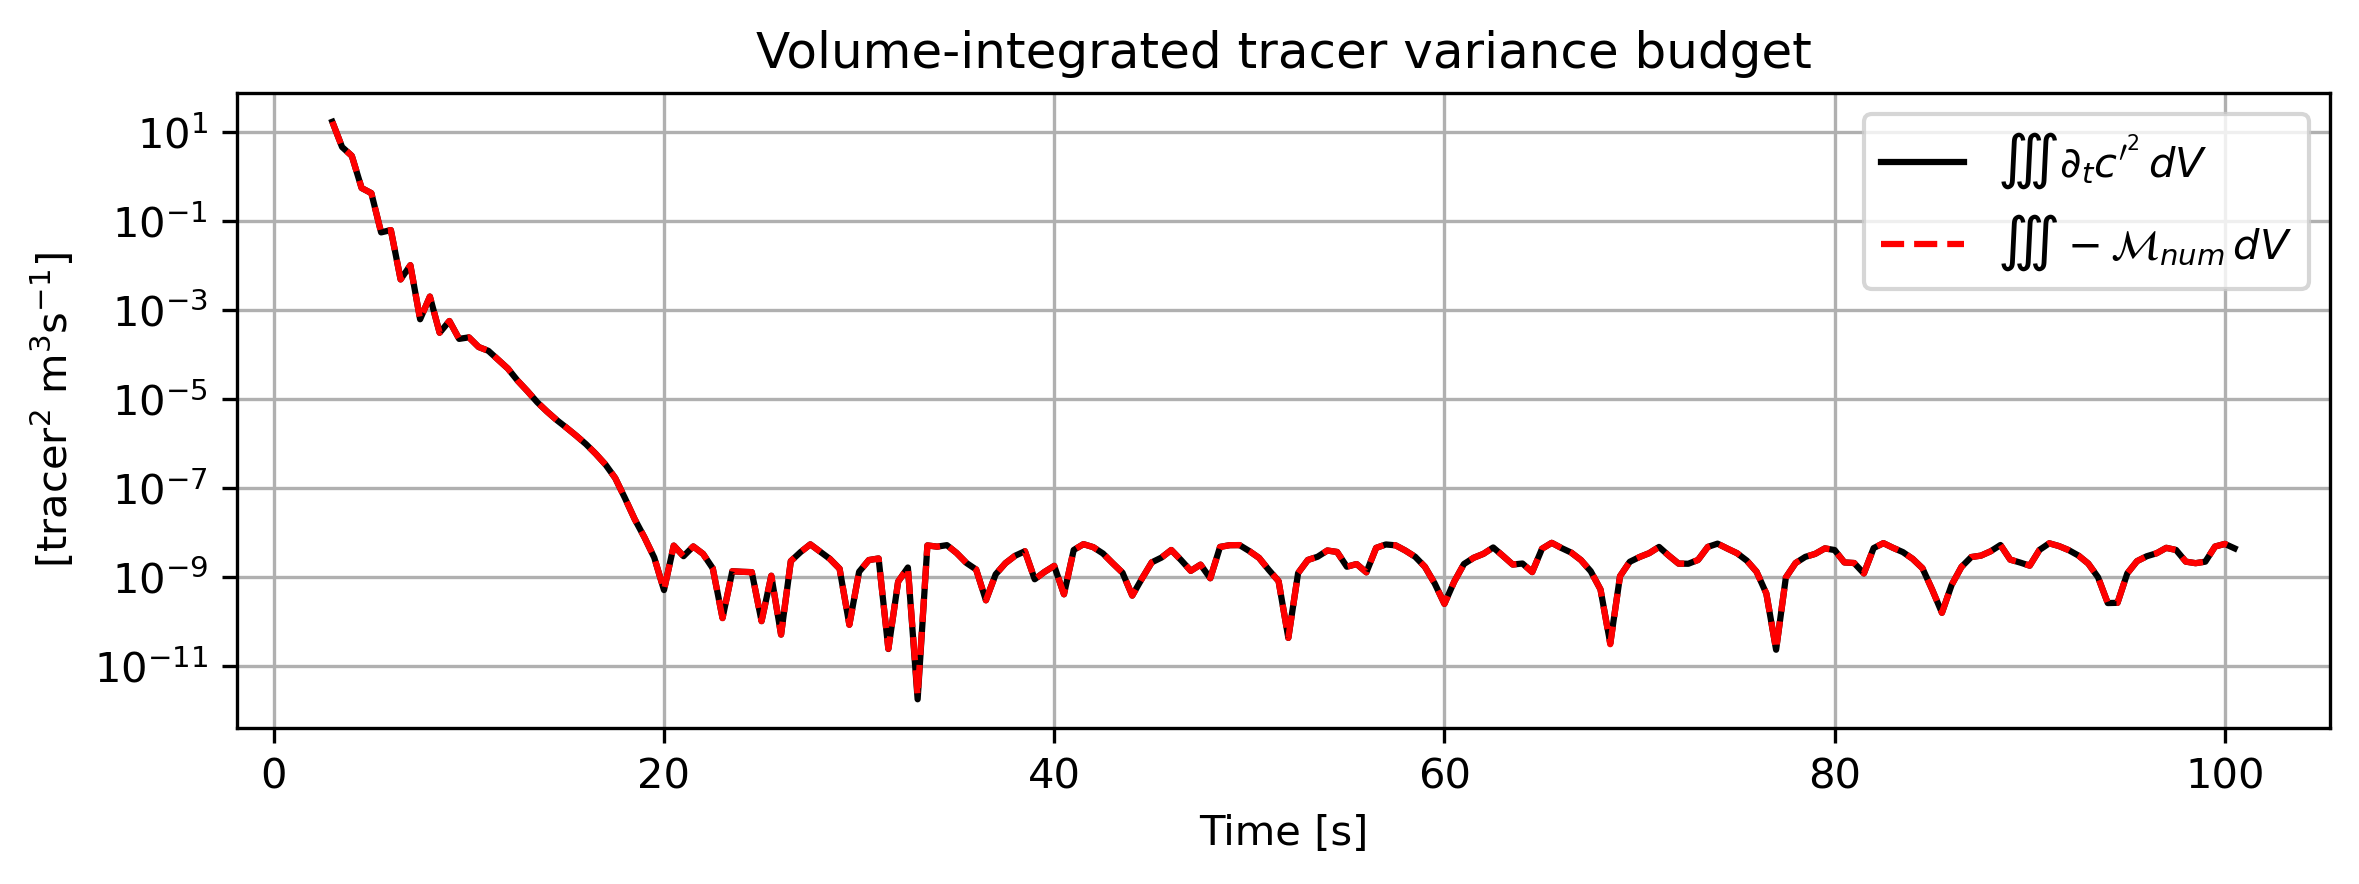

In [25]:
# Total timestep offset:
# 1 (diff) + 2 (AB2 lag) + spinup_cut
offset_steps = 1 + 2 + 3

time = (np.arange(len(tend_slice)) + offset_steps) * dt

# ================================================================
# Plot
# ================================================================

plt.figure(figsize=(9, 2.75), dpi=300)

plt.plot(time, np.abs(tend_slice),
         c='k',
         label=r'$\iiint \partial_t c^{\prime^2} \, dV$')

plt.plot(time, np.abs(mnum_slice),
         c='r',
         ls='--',
         label=r'$\iiint -\mathcal{M}_{num} \, dV$')

plt.xlabel('Time [s]')
plt.ylabel('[tracer$^2$ m$^3$s$^{-1}$]')
plt.title('Volume-integrated tracer variance budget')
plt.grid()
plt.legend()
plt.semilogy()

plt.show()

In [32]:
dso.xtime[:121]

<xarray.DataArray 'xtime' (Time: 121)> Size: 8kB
array([b'0001-01-01_00:00:00', b'0001-01-01_00:00:00', b'0001-01-01_00:00:01',
       b'0001-01-01_00:00:01', b'0001-01-01_00:00:02', b'0001-01-01_00:00:02',
       b'0001-01-01_00:00:03', b'0001-01-01_00:00:03', b'0001-01-01_00:00:04',
       b'0001-01-01_00:00:04', b'0001-01-01_00:00:05', b'0001-01-01_00:00:05',
       b'0001-01-01_00:00:06', b'0001-01-01_00:00:06', b'0001-01-01_00:00:07',
       b'0001-01-01_00:00:07', b'0001-01-01_00:00:08', b'0001-01-01_00:00:08',
       b'0001-01-01_00:00:09', b'0001-01-01_00:00:09', b'0001-01-01_00:00:10',
       b'0001-01-01_00:00:10', b'0001-01-01_00:00:11', b'0001-01-01_00:00:11',
       b'0001-01-01_00:00:12', b'0001-01-01_00:00:12', b'0001-01-01_00:00:13',
       b'0001-01-01_00:00:13', b'0001-01-01_00:00:14', b'0001-01-01_00:00:14',
       b'0001-01-01_00:00:15', b'0001-01-01_00:00:15', b'0001-01-01_00:00:16',
       b'0001-01-01_00:00:16', b'0001-01-01_00:00:17', b'0001-01-01_00:00:17',
       b'0001-01-01_00:00:18', b'0001-01-01_00:00:18', b'0001-01-01_00:00:19',
       b'0001-01-01_00:00:19', b'0001-01-01_00:00:20', b'0001-01-01_00:00:20',
       b'0001-01-01_00:00:21', b'0001-01-01_00:00:21', b'0001-01-01_00:00:22',
       b'0001-01-01_00:00:22', b'0001-01-01_00:00:23', b'0001-01-01_00:00:23',
       b'0001-01-01_00:00:24', b'0001-01-01_00:00:24', b'0001-01-01_00:00:25',
       b'0001-01-01_00:00:25', b'0001-01-01_00:00:26', b'0001-01-01_00:00:26',
       b'0001-01-01_00:00:27', b'0001-01-01_00:00:27', b'0001-01-01_00:00:28',
       b'0001-01-01_00:00:28', b'0001-01-01_00:00:29', b'0001-01-01_00:00:29',
       b'0001-01-01_00:00:30', b'0001-01-01_00:00:30', b'0001-01-01_00:00:31',
       b'0001-01-01_00:00:31', b'0001-01-01_00:00:32', b'0001-01-01_00:00:32',
       b'0001-01-01_00:00:33', b'0001-01-01_00:00:33', b'0001-01-01_00:00:34',
       b'0001-01-01_00:00:34', b'0001-01-01_00:00:35', b'0001-01-01_00:00:35',
       b'0001-01-01_00:00:36', b'0001-01-01_00:00:36', b'0001-01-01_00:00:37',
       b'0001-01-01_00:00:37', b'0001-01-01_00:00:38', b'0001-01-01_00:00:38',
       b'0001-01-01_00:00:39', b'0001-01-01_00:00:39', b'0001-01-01_00:00:40',
       b'0001-01-01_00:00:40', b'0001-01-01_00:00:41', b'0001-01-01_00:00:41',
       b'0001-01-01_00:00:42', b'0001-01-01_00:00:42', b'0001-01-01_00:00:43',
       b'0001-01-01_00:00:43', b'0001-01-01_00:00:44', b'0001-01-01_00:00:44',
       b'0001-01-01_00:00:45', b'0001-01-01_00:00:45', b'0001-01-01_00:00:46',
       b'0001-01-01_00:00:46', b'0001-01-01_00:00:47', b'0001-01-01_00:00:47',
       b'0001-01-01_00:00:48', b'0001-01-01_00:00:48', b'0001-01-01_00:00:49',
       b'0001-01-01_00:00:49', b'0001-01-01_00:00:50', b'0001-01-01_00:00:50',
       b'0001-01-01_00:00:51', b'0001-01-01_00:00:51', b'0001-01-01_00:00:52',
       b'0001-01-01_00:00:52', b'0001-01-01_00:00:53', b'0001-01-01_00:00:53',
       b'0001-01-01_00:00:54', b'0001-01-01_00:00:54', b'0001-01-01_00:00:55',
       b'0001-01-01_00:00:55', b'0001-01-01_00:00:56', b'0001-01-01_00:00:56',
       b'0001-01-01_00:00:57', b'0001-01-01_00:00:57', b'0001-01-01_00:00:58',
       b'0001-01-01_00:00:58', b'0001-01-01_00:00:59', b'0001-01-01_00:00:59',
       b'0001-01-01_00:01:00'], dtype='|S64')
Dimensions without coordinates: Time
Attributes:
    long_name:  model time, with format 'YYYY-MM-DD_HH:MM:SS'

In [37]:
len(np.arange(3,60.5,0.5))

115

In [40]:
dso.xtime

<xarray.DataArray 'xtime' (Time: 201)> Size: 13kB
array([b'0001-01-01_00:00:00', b'0001-01-01_00:00:00', b'0001-01-01_00:00:01',
       ..., b'0001-01-01_00:01:39', b'0001-01-01_00:01:39',
       b'0001-01-01_00:01:40'], dtype='|S64')
Dimensions without coordinates: Time
Attributes:
    long_name:  model time, with format 'YYYY-MM-DD_HH:MM:SS'

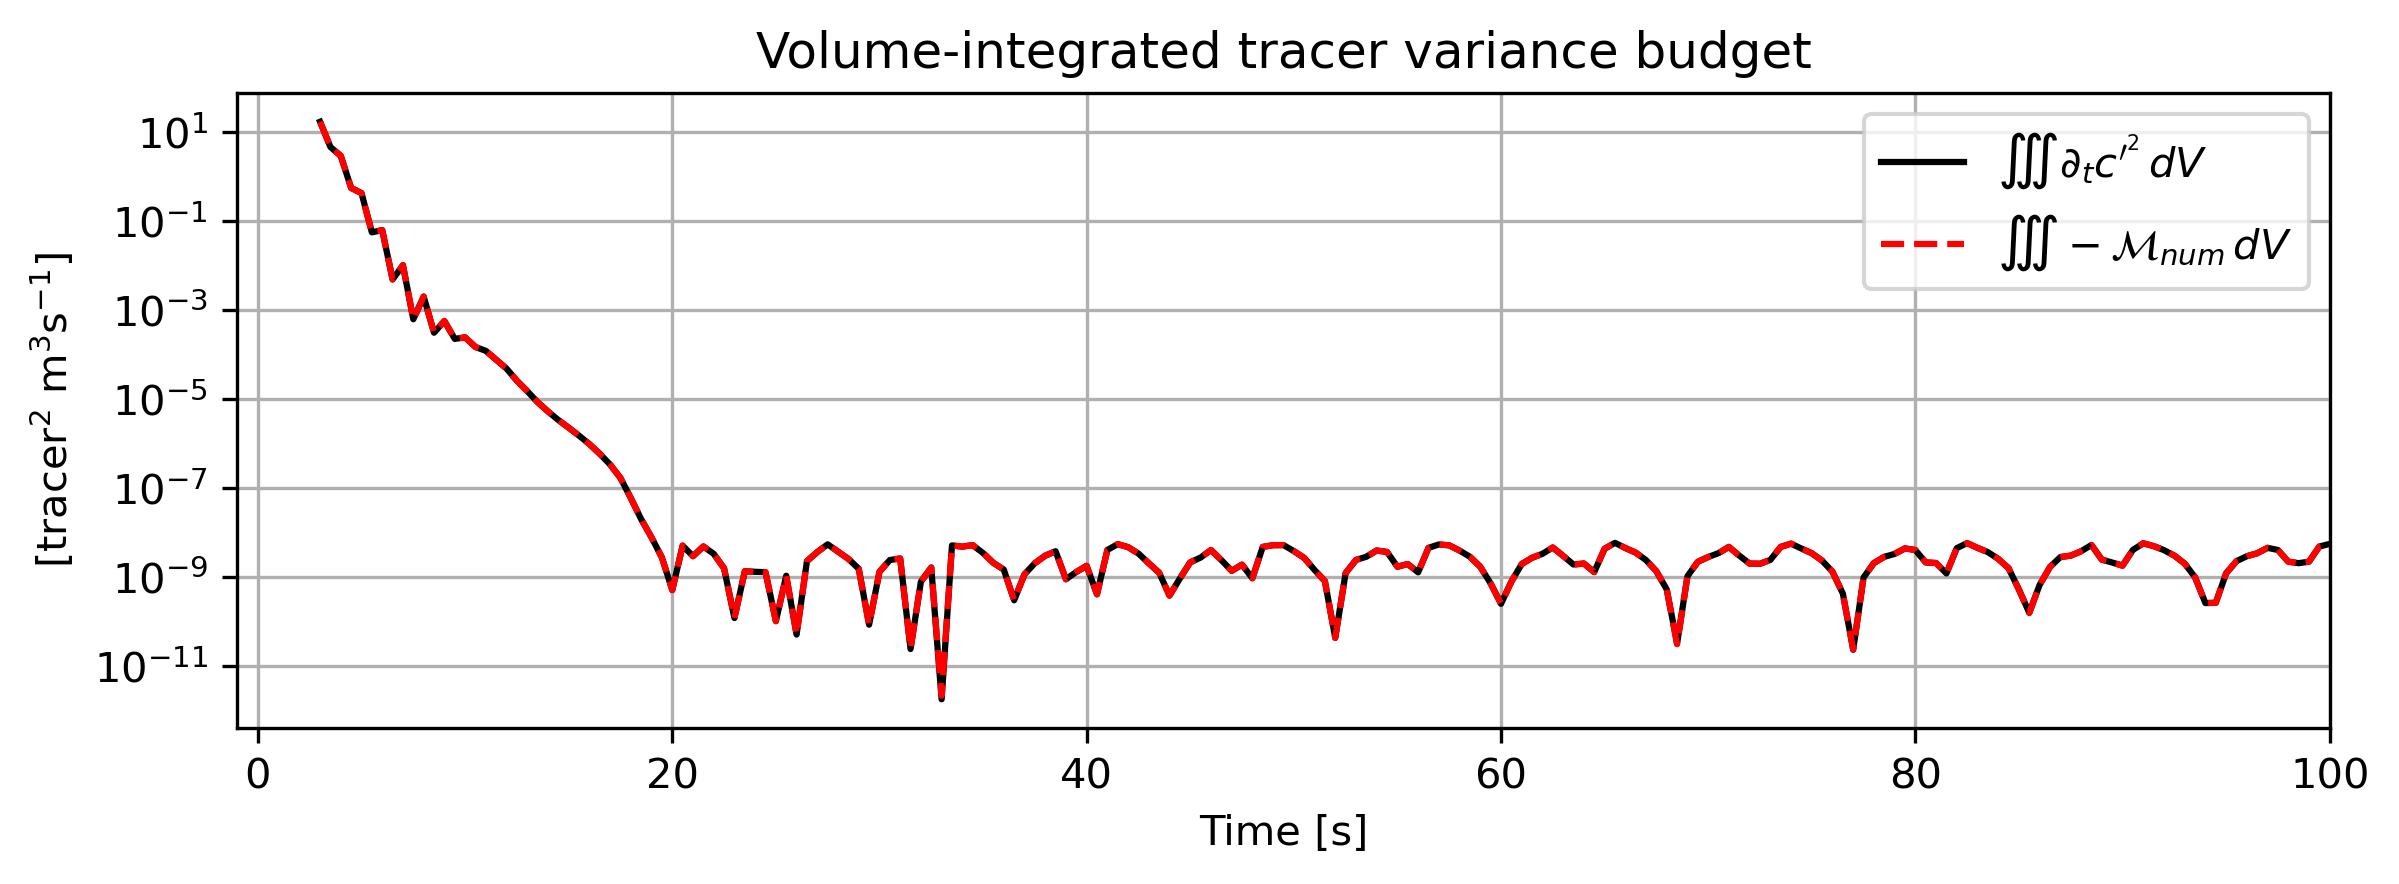

In [48]:
# --- Plotting ---
plt.figure(figsize=(9,2.75),dpi=300)

start_time = 3.0
dt = 0.5
time = start_time + np.arange(len(tend_slice)) * dt

plt.plot(time,np.abs(tend_slice[:196]), c = 'k', label=r'$\iiint \partial_t c^{\prime^2} \, dV$')
plt.plot(time,np.abs(mnum_slice[:196]), c = 'r', ls = '--', label=r'$\iiint -\mathcal{M}_{num} \, dV$')
plt.xlabel('Time [s]')
plt.ylabel('[tracer$^2$ m$^3$s$^{-1}$]')
plt.grid()
plt.xlim(-1,100)
plt.title('Volume-integrated tracer variance budget')
plt.legend()
plt.semilogy()
# plt.show()
plt.savefig('svar_budget_1d_adv.png',bbox_inches='tight', dpi = 300)

In [11]:
# ================================================================
# Conservative salinity variance budget (volume integrated first)
# ================================================================
dV = (dso.layerThickness * dsi.areaCell).astype(np.float64)
V = dV.sum(dim=['nVertLevels', 'nCells'])

# --- Volume-weighted mean salinity ---
sbar = (dso.salinity * dV).sum(
    dim=['nVertLevels', 'nCells']
) / V

# --- Local variance ---
svar = (dso.salinity - sbar)**2

# --- Volume-integrated variance ---
var_int = (svar * dV).sum(
    dim=['nVertLevels', 'nCells']
).astype(np.float64)

# --- Time step ---
dt = np.float64(0.5)

# --- Conservative time tendency of variance ---
tend = var_int.diff('Time') / dt
tend = tend.astype(np.float64)

# ================================================================
# Numerical mixing diagnostic (BR08, AB2)
# ================================================================

mnum_dv = (
    dsd.chiSpurSaltBR08
    * dsi.areaCell
    * dso.layerThickness
).sum(dim=['nVertLevels', 'nCells']).astype(np.float64)

# ------------------------------------------------
# AB2 alignment
# ------------------------------------------------
# - diff() shifts tend forward by 1
# - AB2 introduces a 2-step lag
# - chiSpurSaltBR08 undefined at t0
# Therefore shift numerical mixing forward by 2
# and flip sign to match variance tendency convention

mnum_aligned = -mnum_dv.isel(
    Time=slice(2, 2 + len(tend))
)

# ------------------------------------------------
# Remove startup transients
# ------------------------------------------------
spinup_cut = 3

tend_slice = tend.isel(Time=slice(spinup_cut, None))
mnum_slice = mnum_aligned.isel(Time=slice(spinup_cut, None))

# Ensure identical lengths (no silent mismatch)
min_len = min(len(tend_slice), len(mnum_slice))
tend_slice = tend_slice.isel(Time=slice(0, min_len))
mnum_slice = mnum_slice.isel(Time=slice(0, min_len))

print(len(mnum_slice), len(tend_slice))

# ================================================================
# Closure check
# ================================================================

total_tend = tend_slice.sum()
total_mnum = mnum_slice.sum()

print(f"Integrated variance tendency: {float(total_tend):.12e}")
print(f"Integrated numerical mixing:  {float(total_mnum):.12e}")

196 196
Integrated variance tendency: 2.623454784102e+01
Integrated numerical mixing:  2.623454784102e+01
